In [1]:
import numpy as np
import pandas as pd
import matplotlib as pyplot
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers (1).csv to Mall_Customers (1).csv


In [3]:
df = pd.read_csv('Mall_Customers (1).csv')

In [4]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
display(df.describe())

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df_clustering = df.drop('CustomerID', axis=1)
display(df_clustering.head())

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [7]:
df_clustering = pd.get_dummies(df_clustering, columns=['Genre'], drop_first=True)
display(df_clustering.head())

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_clustering)
df_scaled = pd.DataFrame(data_scaled, columns=df_clustering.columns)
display(df_scaled.head())

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


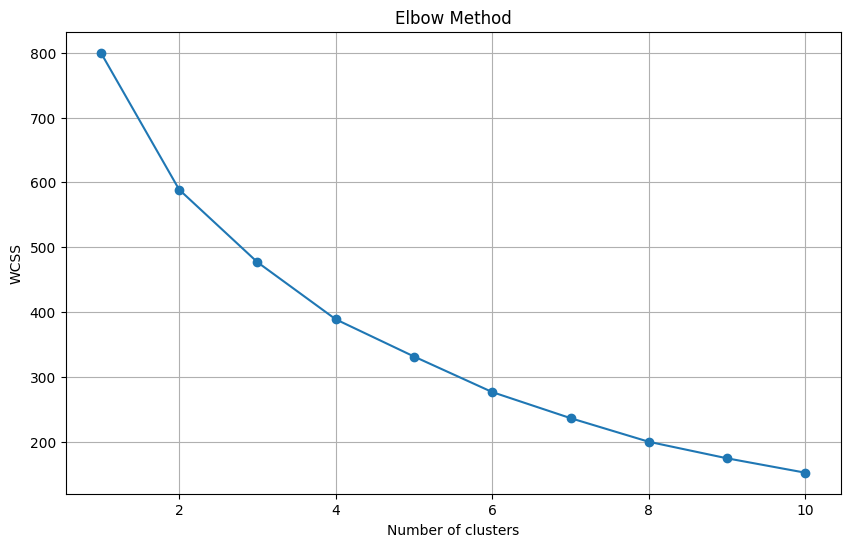

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

fig = plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(df_scaled)

df_clustering['Cluster'] = y_kmeans
display(df_clustering.head())

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,Cluster
0,19,15,39,True,3
1,21,15,81,True,3
2,20,16,6,False,3
3,23,16,77,False,3
4,31,17,40,False,3


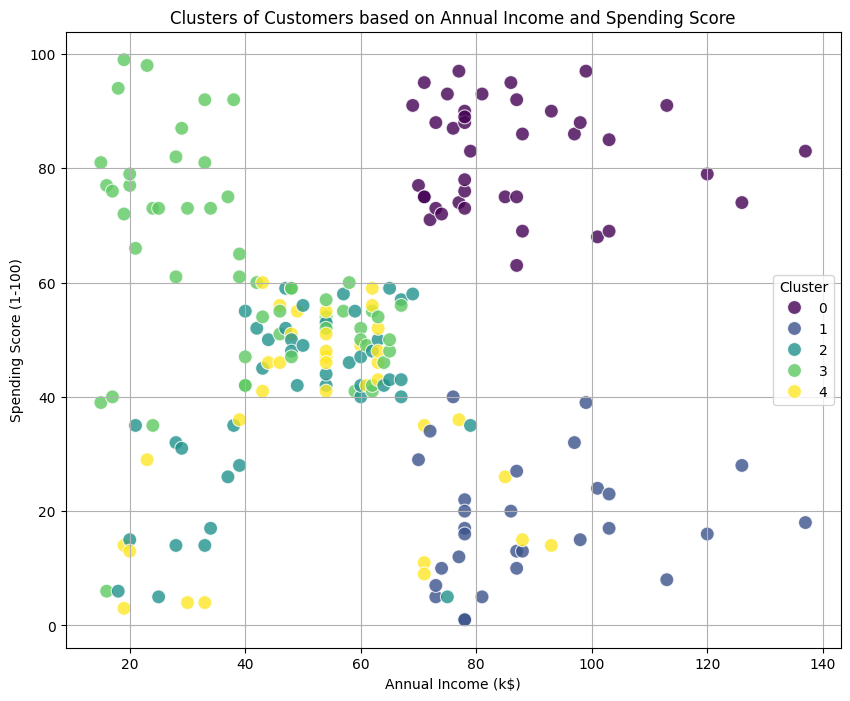

In [15]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_clustering, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters of Customers based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

In [17]:
cluster_summary = df_clustering.groupby('Cluster').mean()
display(cluster_summary)

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
Cluster,,,,
0,32.692308,86.538462,82.128205,0.461538
1,36.482759,89.517241,18.000000,0.448276
2,49.813953,49.232558,40.069767,0.000000
3,24.907407,39.722222,61.203704,0.407407
4,55.714286,53.685714,36.771429,1.000000


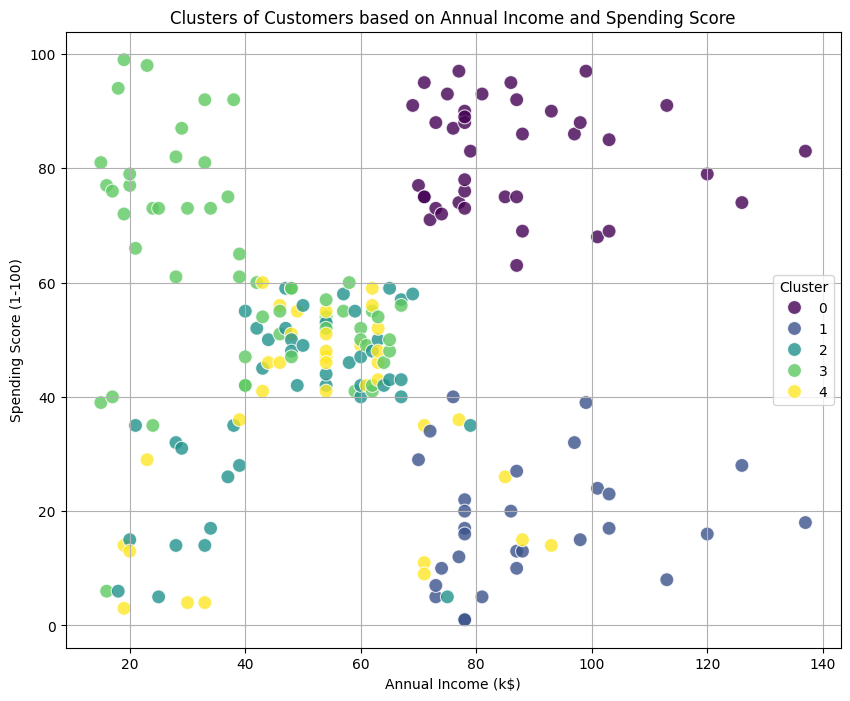

In [12]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_clustering, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters of Customers based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

In [14]:
cluster_summary = df_clustering.groupby('Cluster').mean()
display(cluster_summary)

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
Cluster,,,,
0,32.692308,86.538462,82.128205,0.461538
1,36.482759,89.517241,18.000000,0.448276
2,49.813953,49.232558,40.069767,0.000000
3,24.907407,39.722222,61.203704,0.407407
4,55.714286,53.685714,36.771429,1.000000
